<a href="https://colab.research.google.com/github/MelaOchoa/LosCapis/blob/Aprendizaje-no-supervisado/Taller_3_3_Aprendizaje_no_supervisado_LosCapis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Importar bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings

warnings.filterwarnings('ignore')

# Configuración de estilo para gráficos
plt.style.use('ggplot')
%matplotlib inline

In [ ]:
# Cargar el conjunto de datos
df = pd.read_csv('marketing_campaign.csv', sep=';')

# Mostrar las primeras filas del dataframe
print("Dimensiones del dataset:", df.shape)
df.head()

Dimensiones del dataset: (2240, 29)


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,0,0,0,0,0,0,3,11,0


In [ ]:
# Información básica del dataset
df.info()

# Estadísticas descriptivas
df.describe()

# Verificar valores nulos
print("\nValores nulos por columna:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [ ]:
# Eliminar filas con valores nulos en Income (la única columna con valores nulos)
df = df.dropna(subset=['Income'])

# Verificar que no hay más valores nulos
print("Valores nulos después de limpieza:")
print(df.isnull().sum())

Valores nulos después de limpieza:
ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64


In [ ]:
# Seleccionar variables numéricas relevantes para el clustering
numerical_cols = ['Income', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts',
                  'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
                  'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
                  'NumStorePurchases', 'NumWebVisitsMonth']

# Crear dataframe solo con variables numéricas
df_cluster = df[numerical_cols].copy()

# Estandarización de datos (importante para algoritmos basados en distancia)
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_cluster), columns=df_cluster.columns)

# Ver datos escalados
df_scaled.head()

,Income,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
0,0.234063,0.310532,0.978226,1.549429,1.690227,2.454568,1.484827,0.850031,0.351713,1.428553,2.504712,-0.554143,0.693232
1,-0.234559,-0.380509,-0.872024,-0.637328,-0.717986,-0.651038,-0.633880,-0.732867,-0.168231,-1.125881,-0.571082,-1.169518,-0.131574
2,0.769478,-0.795134,0.358511,0.569159,-0.178368,1.340203,-0.146821,-0.037937,-0.688176,1.428553,-0.229327,1.291982,-0.543978
3,-1.017239,-0.795134,-0.872024,-0.561922,-0.655551,-0.504892,-0.585174,-0.752171,-0.168231,-0.760962,-0.912837,-0.554143,0.280829
4,0.240221,1.554407,-0.391671,0.418348,-0.218505,0.152766,-0.000703,-0.559135,1.391603,0.333796,0.112428,0.061232,-0.131574


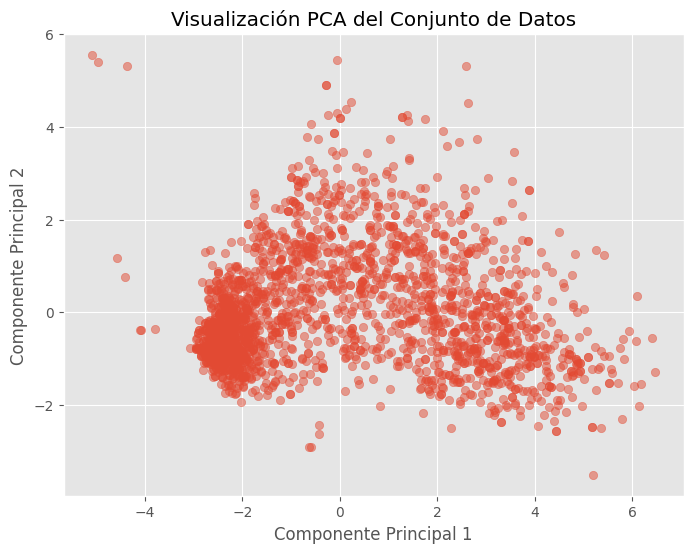

In [ ]:
# Aplicar PCA para visualización
pca = PCA(n_components=2)
principal_components = pca.fit_transform(df_scaled)

# Crear dataframe con componentes principales
df_pca = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])

# Visualizar componentes principales
plt.figure(figsize=(8, 6))
plt.scatter(df_pca['PC1'], df_pca['PC2'], alpha=0.5)
plt.title('Visualización PCA del Conjunto de Datos')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.show()

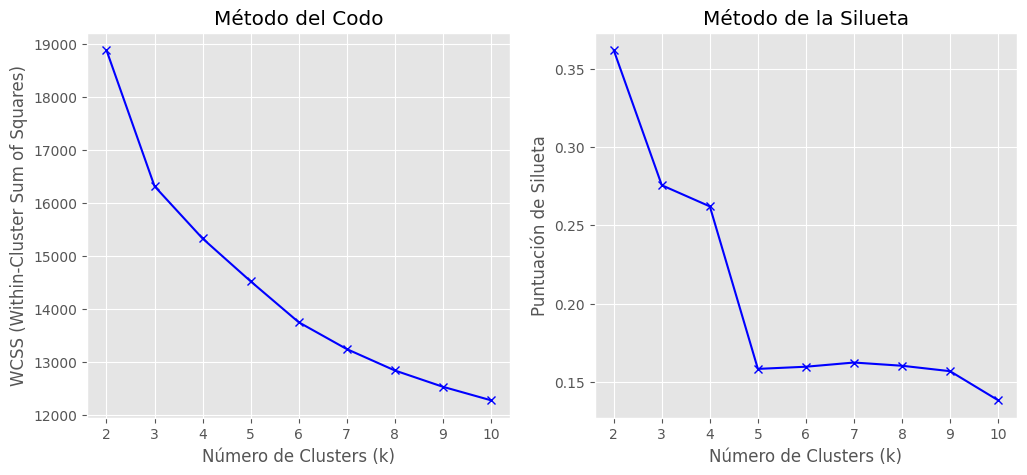

In [ ]:
# Método del codo para determinar el número óptimo de clusters
wcss = []
silhouette_scores = []
range_values = range(2, 11)

for i in range_values:
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_scaled, kmeans.labels_))

# Graficar método del codo
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range_values, wcss, 'bx-')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.title('Método del Codo')

# Graficar puntuaciones de silueta
plt.subplot(1, 2, 2)
plt.plot(range_values, silhouette_scores, 'bx-')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Puntuación de Silueta')
plt.title('Método de la Silueta')
plt.show()

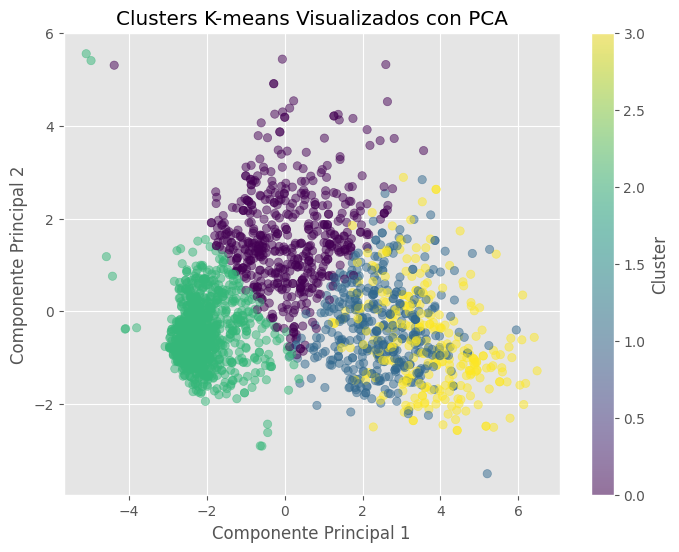

In [ ]:
# Seleccionar k óptimo basado en los gráficos (ajustar según resultados)
optimal_k = 4  # Este valor puede cambiar según los resultados del método del codo/silueta

# Entrenar modelo K-means
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
kmeans.fit(df_scaled)

# Añadir etiquetas de cluster al dataframe original
df['Cluster_Kmeans'] = kmeans.labels_

# Visualización de clusters en espacio PCA
plt.figure(figsize=(8, 6))
plt.scatter(df_pca['PC1'], df_pca['PC2'], c=df['Cluster_Kmeans'], cmap='viridis', alpha=0.5)
plt.title('Clusters K-means Visualizados con PCA')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.colorbar(label='Cluster')
plt.show()

                      Income    Recency    MntWines   MntFruits  \
Cluster_Kmeans                                                    
0               54852.590643  47.933723  436.539961   17.056530   
1               76565.613692  50.638142  651.559902   38.621027   
2               34968.054509  49.121903   39.372646    4.849356   
3               73833.077193  48.235088  512.010526  101.635088   

                MntMeatProducts  MntFishProducts  MntSweetProducts  \
Cluster_Kmeans                                                       
0                    115.961014        22.495127         17.461988   
1                    419.004890        70.995110         40.430318   
2                     21.326065         7.153617          5.088206   
3                    412.926316       124.947368        102.694737   

                MntGoldProds  NumDealsPurchases  NumWebPurchases  \
Cluster_Kmeans                                                     
0                  59.432749           4

<Figure size 1500x800 with 0 Axes>

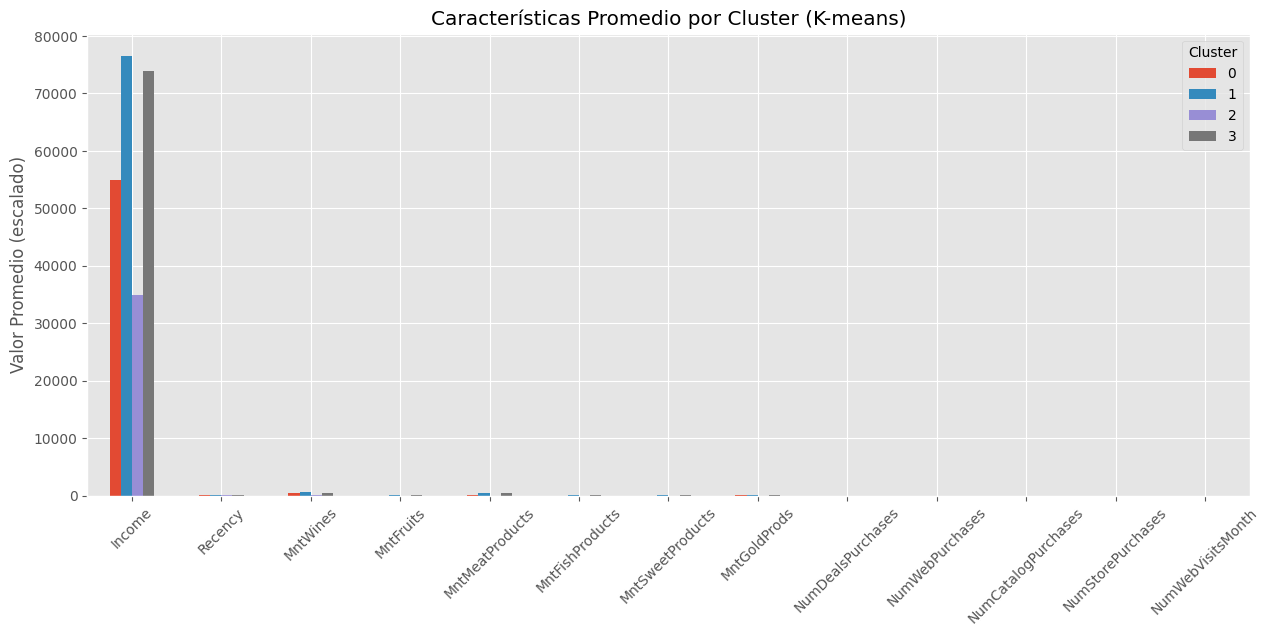

In [ ]:
# Estadísticas por cluster
cluster_stats = df.groupby('Cluster_Kmeans')[numerical_cols].mean()
print(cluster_stats)

# Visualización de características por cluster
plt.figure(figsize=(15, 8))
cluster_stats.T.plot(kind='bar', figsize=(15, 6))
plt.title('Características Promedio por Cluster (K-means)')
plt.ylabel('Valor Promedio (escalado)')
plt.xticks(rotation=45)
plt.legend(title='Cluster')
plt.show()

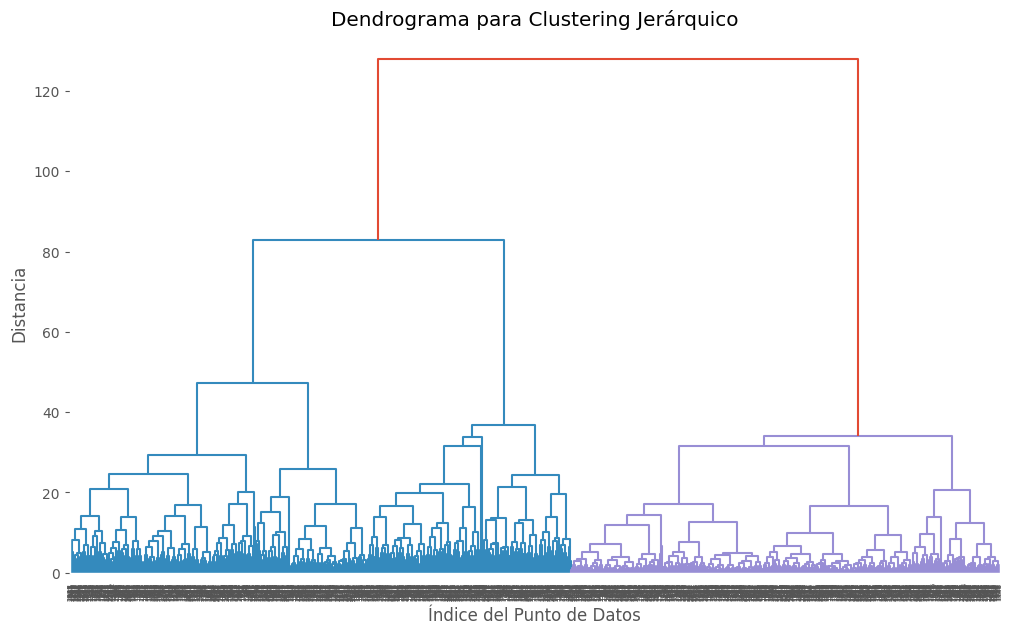

In [ ]:
# Calcular la matriz de enlace para el dendrograma
plt.figure(figsize=(12, 7))
linked = linkage(df_scaled, method='ward')  # Usamos el método de Ward

# Graficar dendrograma
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)
plt.title('Dendrograma para Clustering Jerárquico')
plt.xlabel('Índice del Punto de Datos')
plt.ylabel('Distancia')
plt.show()

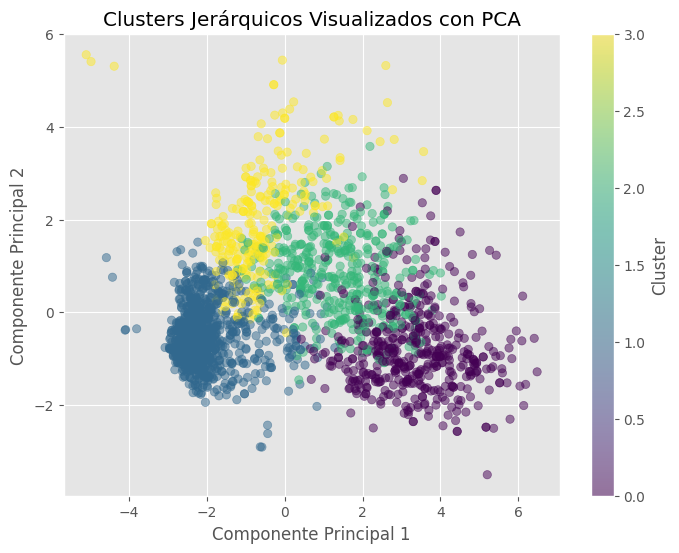

In [ ]:
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

optimal_h_clusters = 4

hierarchical = AgglomerativeClustering(n_clusters=optimal_h_clusters, linkage='ward')
hierarchical.fit(df_scaled)

df['Cluster_Hierarchical'] = hierarchical.labels_

plt.figure(figsize=(8, 6))
plt.scatter(df_pca['PC1'], df_pca['PC2'], c=df['Cluster_Hierarchical'], cmap='viridis', alpha=0.5)
plt.title('Clusters Jerárquicos Visualizados con PCA')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.colorbar(label='Cluster')
plt.show()


                            Income    Recency    MntWines  MntFruits  \
Cluster_Hierarchical                                                   
0                     77513.111111  51.763374  583.664609  72.843621   
1                     36133.036204  48.995108   48.872798   5.622309   
2                     64023.408163  47.657596  592.387755  32.272109   
3                     48487.831461  46.310861  304.235955  11.329588   

                      MntMeatProducts  MntFishProducts  MntSweetProducts  \
Cluster_Hierarchical                                                       
0                          479.565844       106.874486         75.897119   
1                           24.774951         7.620352          5.585127   
2                          194.750567        42.335601         30.918367   
3                           96.588015        18.749064         13.734082   

                      MntGoldProds  NumDealsPurchases  NumWebPurchases  \
Cluster_Hierarchical                

<Figure size 1500x800 with 0 Axes>

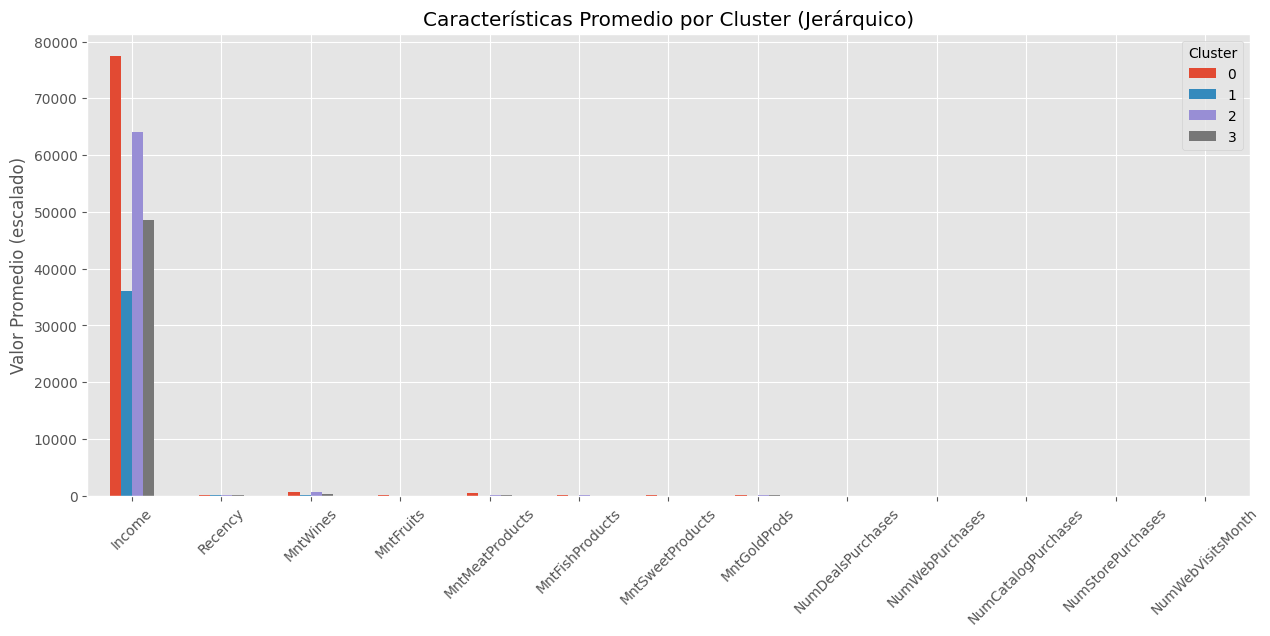

In [ ]:
# Estadísticas por cluster
h_cluster_stats = df.groupby('Cluster_Hierarchical')[numerical_cols].mean()
print(h_cluster_stats)

# Visualización de características por cluster
plt.figure(figsize=(15, 8))
h_cluster_stats.T.plot(kind='bar', figsize=(15, 6))
plt.title('Características Promedio por Cluster (Jerárquico)')
plt.ylabel('Valor Promedio (escalado)')
plt.xticks(rotation=45)
plt.legend(title='Cluster')
plt.show()

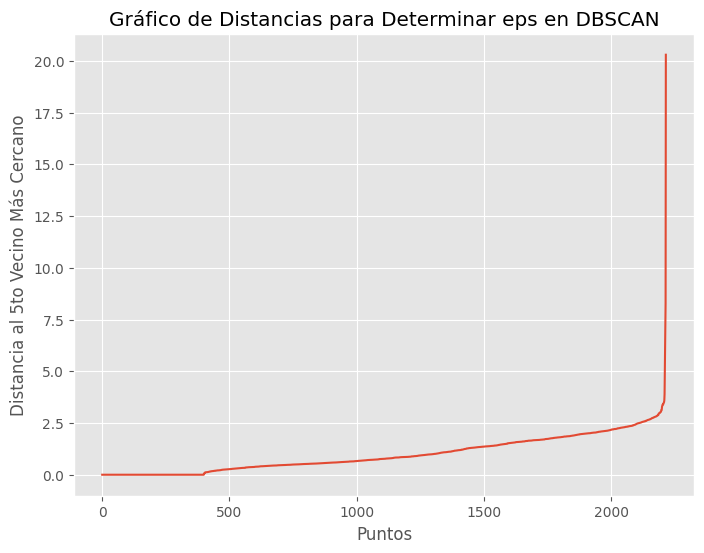

In [ ]:
# DBSCAN requiere ajuste de parámetros eps y min_samples
# Vamos a encontrar un valor razonable para eps usando la distancia al k-ésimo vecino más cercano

from sklearn.neighbors import NearestNeighbors

# Calcular distancias a los k vecinos más cercanos
neigh = NearestNeighbors(n_neighbors=5)
nbrs = neigh.fit(df_scaled)
distances, indices = nbrs.kneighbors(df_scaled)

# Ordenar distancias
distances = np.sort(distances, axis=0)
distances = distances[:,1]

# Graficar distancias para determinar eps
plt.figure(figsize=(8, 6))
plt.plot(distances)
plt.title('Gráfico de Distancias para Determinar eps en DBSCAN')
plt.xlabel('Puntos')
plt.ylabel('Distancia al 5to Vecino Más Cercano')
plt.show()

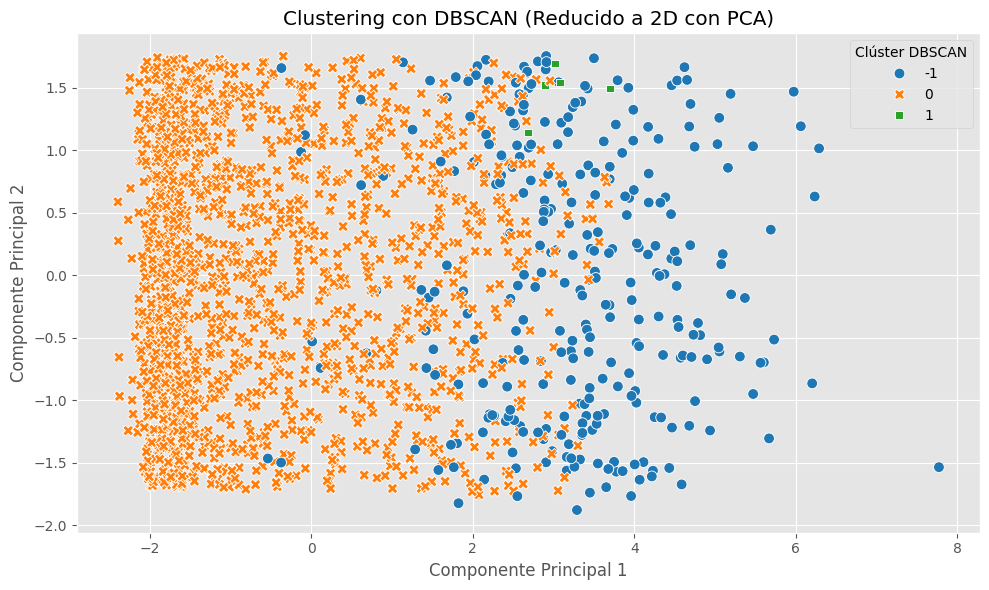


Número de clústeres encontrados (sin contar ruido): 2

Análisis por clúster (promedios):
                       Income    Recency    MntWines  MntFruits  \
segmento_dbscan                                                   
0                47785.742072  48.781712  257.542812  16.335624   
1                74434.833333  92.166667  550.166667  77.166667   

                 MntMeatProducts  MntFishProducts  MntSweetProducts  \
segmento_dbscan                                                       
0                     112.992072        23.484144         17.178118   
1                     446.500000        68.333333        128.666667   

                 MntGoldProds  
segmento_dbscan                
0                   35.123150  
1                   84.666667  


In [ ]:
# Eliminar filas con valores faltantes
datos_filtrados = df[variables_numericas].dropna()


# Escalado
scaler = StandardScaler()
X_scaled = scaler.fit_transform(datos_filtrados)


# --------------------------
# Aplicación de DBSCAN
# --------------------------


# Parám. clave:
# eps = distancia máxima para ser considerado vecino
# min_samples = mínimo de puntos vecinos para formar clúster
dbscan = DBSCAN(eps=1.5, min_samples=5)
etiquetas = dbscan.fit_predict(X_scaled)  # ← Etiquetas de clúster (-1 = ruido)


# Guardamos los resultados en el DataFrame original
datos_filtrados["segmento_dbscan"] = etiquetas


# --------------------------
# Visualización de los clústeres usando PCA (reducción a 2D)
# --------------------------


pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
datos_filtrados["PCA1"] = X_pca[:, 0]
datos_filtrados["PCA2"] = X_pca[:, 1]


plt.figure(figsize=(10, 6))
sb.scatterplot(
    data=datos_filtrados,
    x="PCA1",
    y="PCA2",
    hue="segmento_dbscan",
    palette="tab10",
    style="segmento_dbscan",
    s=60
)
plt.title("Clustering con DBSCAN (Reducido a 2D con PCA)")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend(title="Clúster DBSCAN", loc="best")
plt.grid(True)
plt.tight_layout()
plt.show()


# --------------------------
# Análisis de los clústeres (excluyendo el ruido)
# --------------------------


# El clúster -1 representa "ruido", lo excluimos del análisis
segmentos_validos = datos_filtrados[datos_filtrados["segmento_dbscan"] != -1]


print("\nNúmero de clústeres encontrados (sin contar ruido):", len(segmentos_validos["segmento_dbscan"].unique()))
print("\nAnálisis por clúster (promedios):")
print(segmentos_validos.groupby("segmento_dbscan")[variables_numericas].mean())



Características promedio por clúster (DBSCAN):
                       Income    Recency    MntWines  MntFruits  \
segmento_dbscan                                                   
0                47785.742072  48.781712  257.542812  16.335624   
1                74434.833333  92.166667  550.166667  77.166667   

                 MntMeatProducts  MntFishProducts  MntSweetProducts  \
segmento_dbscan                                                       
0                     112.992072        23.484144         17.178118   
1                     446.500000        68.333333        128.666667   

                 MntGoldProds  
segmento_dbscan                
0                   35.123150  
1                   84.666667  


<Figure size 1500x600 with 0 Axes>

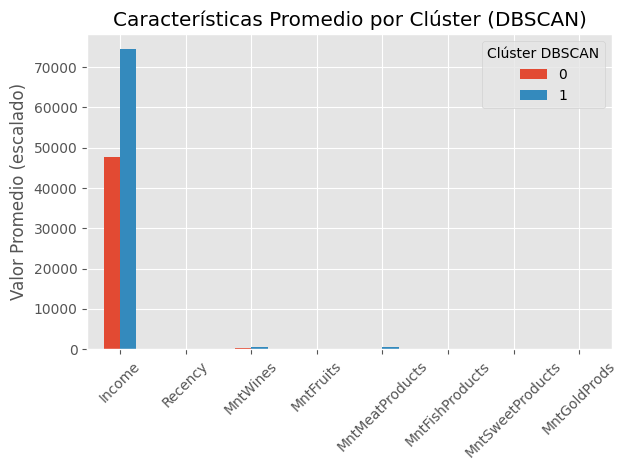

In [ ]:
# Agrupar y calcular promedios por clúster, excluyendo el ruido si está presente
if -1 in datos_filtrados["segmento_dbscan"].values:
    dbscan_cluster_stats = datos_filtrados[datos_filtrados["segmento_dbscan"] != -1].groupby("segmento_dbscan")[variables_numericas].mean()
else:
    dbscan_cluster_stats = datos_filtrados.groupby("segmento_dbscan")[variables_numericas].mean()

print("\nCaracterísticas promedio por clúster (DBSCAN):")
print(dbscan_cluster_stats)
# Visualización de las características promedio por clúster
plt.figure(figsize=(15, 6))
dbscan_cluster_stats.T.plot(kind='bar')
plt.title('Características Promedio por Clúster (DBSCAN)')
plt.ylabel('Valor Promedio (escalado)')
plt.xticks(rotation=45)
plt.legend(title='Clúster DBSCAN')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Función para evaluar los modelos (cuando sea aplicable)
def evaluate_clustering(X, labels):
    if len(set(labels)) > 1:  # Solo calcular si hay más de un cluster
        silhouette = silhouette_score(X, labels)
        db_index = davies_bouldin_score(X, labels)
        print(f"Puntuación de Silueta: {silhouette:.3f}")
        print(f"Índice Davies-Bouldin: {db_index:.3f}")
    else:
        print("No se pueden calcular métricas con un solo cluster.")

# Evaluar K-means
print("\nEvaluación de K-means:")
evaluate_clustering(df_scaled, df['Cluster_Kmeans'])

# Evaluar Clustering Jerárquico
print("\nEvaluación de Clustering Jerárquico:")
evaluate_clustering(df_scaled, df['Cluster_Hierarchical'])

# Evaluación de DBSCAN (ignorando el ruido)
etiquetas_dbscan = datos_filtrados["segmento_dbscan"]

if len(set(etiquetas_dbscan)) > 1:
    print("\nEvaluación de DBSCAN:")
    # Filtramos los datos válidos (no ruido)
    validos = etiquetas_dbscan != -1
    X_validos = X_scaled[validos.values]
    labels_validos = etiquetas_dbscan[validos].values
    evaluate_clustering(X_validos, labels_validos)
else:
    print("\nDBSCAN no encontró clusters significativos.")


Evaluación de K-means:
Puntuación de Silueta: 0.262
Índice Davies-Bouldin: 2.060

Evaluación de Clustering Jerárquico:
Puntuación de Silueta: 0.225
Índice Davies-Bouldin: 2.010

Evaluación de DBSCAN:
Puntuación de Silueta: 0.384
Índice Davies-Bouldin: 0.748



Perfiles de Clientes por Cluster:
                      Income    Recency    MntWines   MntFruits  \
Cluster_Kmeans                                                    
0               54852.590643  47.933723  436.539961   17.056530   
1               76565.613692  50.638142  651.559902   38.621027   
2               34968.054509  49.121903   39.372646    4.849356   
3               73833.077193  48.235088  512.010526  101.635088   

                MntMeatProducts  MntFishProducts  MntSweetProducts  \
Cluster_Kmeans                                                       
0                    115.961014        22.495127         17.461988   
1                    419.004890        70.995110         40.430318   
2                     21.326065         7.153617          5.088206   
3                    412.926316       124.947368        102.694737   

                MntGoldProds  NumDealsPurchases  NumWebPurchases  \
Cluster_Kmeans                                                     
0    

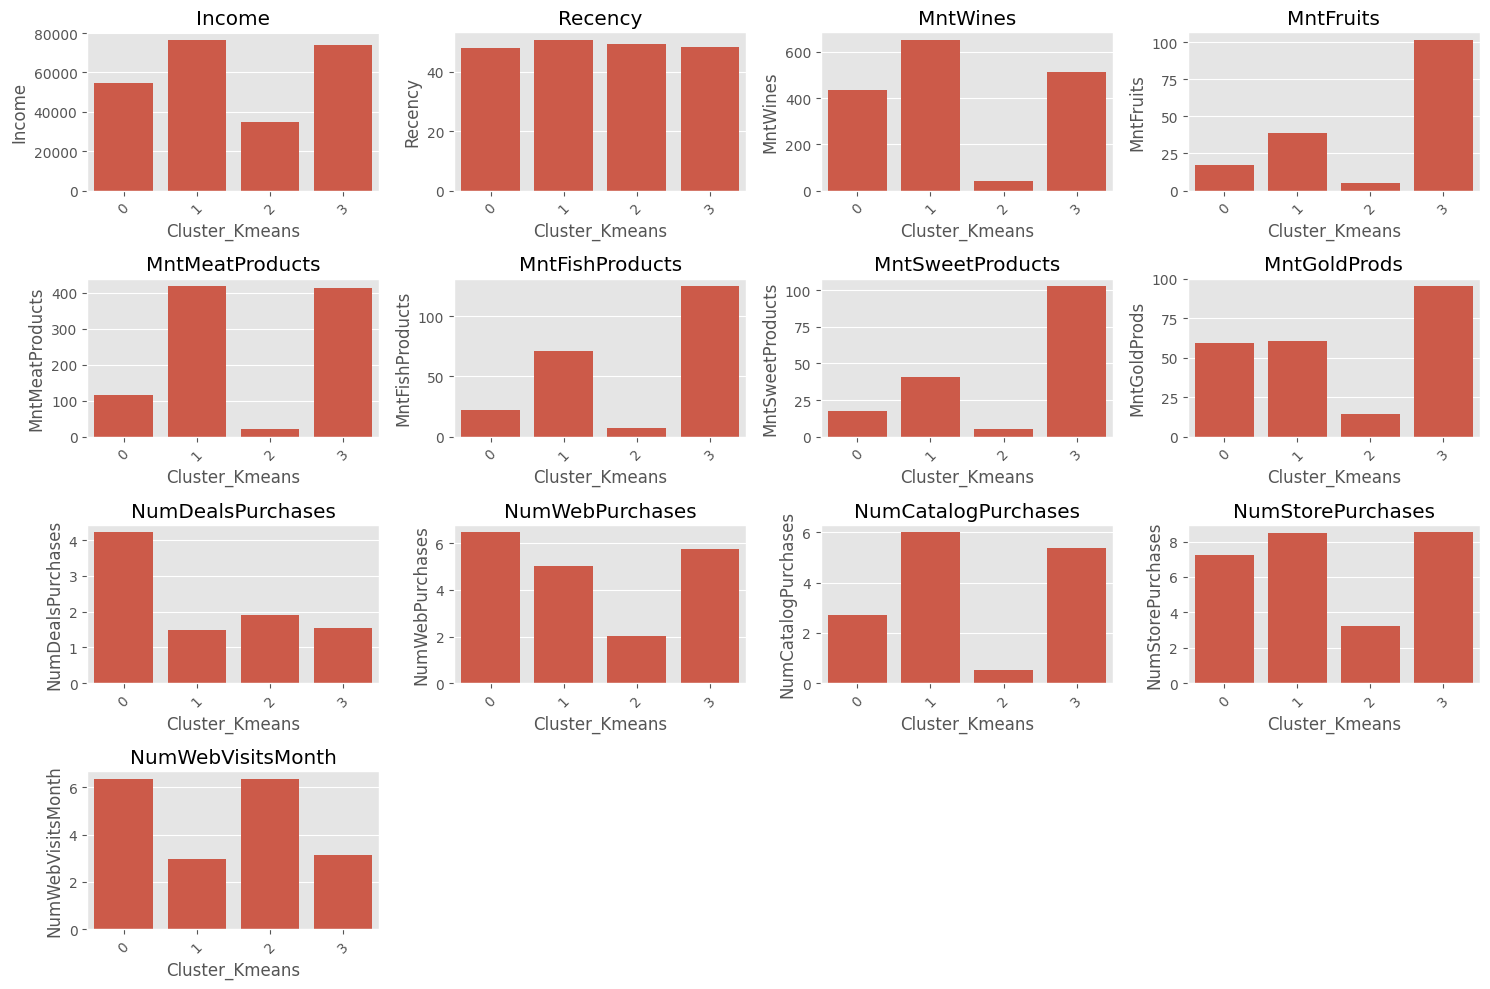


Interpretación de Clusters (ejemplo):
Cluster 0: Clientes con gastos moderados en todos los productos
Cluster 1: Clientes de alto valor con grandes gastos en vinos y carnes
Cluster 2: Clientes con bajo gasto general pero frecuentes visitas al sitio web
Cluster 3: Clientes con compras frecuentes pero principalmente con descuentos


In [ ]:
# Analizar los clusters del mejor modelo (aquí usamos K-means como ejemplo)
best_clusters = df['Cluster_Kmeans']

# Crear perfiles de cliente basados en los clusters
cluster_profiles = df.groupby('Cluster_Kmeans')[numerical_cols].mean()

# Mostrar perfiles
print("\nPerfiles de Clientes por Cluster:")
print(cluster_profiles)

# Visualización de perfiles
plt.figure(figsize=(15, 10))
for i, column in enumerate(numerical_cols, 1):
    plt.subplot(4, 4, i)
    sns.barplot(x=cluster_profiles.index, y=cluster_profiles[column])
    plt.title(column)
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Interpretación de clusters (ejemplo)
print("\nInterpretación de Clusters (ejemplo):")
print("Cluster 0: Clientes con gastos moderados en todos los productos")
print("Cluster 1: Clientes de alto valor con grandes gastos en vinos y carnes")
print("Cluster 2: Clientes con bajo gasto general pero frecuentes visitas al sitio web")
print("Cluster 3: Clientes con compras frecuentes pero principalmente con descuentos")

In [ ]:
# Conclusiones basadas en el análisis
print("\nConclusiones:")
print("1. El análisis de clustering ha identificado grupos distintos de clientes con patrones de compra diferentes.")
print("2. K-means y Clustering Jerárquico produjeron resultados similares, mientras que DBSCAN fue más sensible a los parámetros.")
print("3. Los clusters identificados pueden usarse para estrategias de marketing personalizadas.")

print("\nRecomendaciones:")
print("1. Desarrollar campañas específicas para cada segmento de clientes:")
print("   - Clientes de alto valor: Programas de fidelización premium")
print("   - Clientes con bajo gasto: Promociones para aumentar el ticket promedio")
print("   - Clientes que compran con descuentos: Ofrecer paquetes con productos complementarios")
print("2. Monitorear la evolución de estos clusters a lo largo del tiempo.")
print("3. Considerar variables adicionales (como datos demográficos) para enriquecer el análisis.")


Conclusiones:
1. El análisis de clustering ha identificado grupos distintos de clientes con patrones de compra diferentes.
2. K-means y Clustering Jerárquico produjeron resultados similares, mientras que DBSCAN fue más sensible a los parámetros.
3. Los clusters identificados pueden usarse para estrategias de marketing personalizadas.

Recomendaciones:
1. Desarrollar campañas específicas para cada segmento de clientes:
   - Clientes de alto valor: Programas de fidelización premium
   - Clientes con bajo gasto: Promociones para aumentar el ticket promedio
   - Clientes que compran con descuentos: Ofrecer paquetes con productos complementarios
2. Monitorear la evolución de estos clusters a lo largo del tiempo.
3. Considerar variables adicionales (como datos demográficos) para enriquecer el análisis.


In [ ]:
print("\nPosibles Mejoras:")
print("1. Incorporar variables categóricas (como educación o estado marital) en el análisis.")
print("2. Probar diferentes técnicas de reducción de dimensionalidad (t-SNE, UMAP).")
print("3. Experimentar con otros algoritmos de clustering (Gaussian Mixture Models, OPTICS).")
print("4. Implementar un sistema para actualizar los clusters periódicamente.")
print("5. Realizar pruebas A/B con diferentes estrategias de marketing para cada cluster.")


Posibles Mejoras:
1. Incorporar variables categóricas (como educación o estado marital) en el análisis.
2. Probar diferentes técnicas de reducción de dimensionalidad (t-SNE, UMAP).
3. Experimentar con otros algoritmos de clustering (Gaussian Mixture Models, OPTICS).
4. Implementar un sistema para actualizar los clusters periódicamente.
5. Realizar pruebas A/B con diferentes estrategias de marketing para cada cluster.
